In [20]:
import numpy as np
import pandas as pd
from tensorflow import keras
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
class NN:
    def __init__(self, input_size=784, hidden_nodes=128, output_size=10):
        self.weights1 = np.random.randn(input_size, hidden_nodes) * np.sqrt(2 / input_size)
        self.weights2 = np.random.randn(hidden_nodes, output_size) * np.sqrt(2 / hidden_nodes)
        self.bias1 = np.zeros((1, hidden_nodes))
        self.bias2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, x):
        self.x = x
        self.z1 = x @ self.weights1 + self.bias1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.weights2 + self.bias2
        self.a2 = self.softmax(self.z2)
        return self.a2

    def cross_entropy(self, pred, y):
        epsilon = 1e-10
        correct_probs = pred[np.arange(len(y)), y]
        loss = -np.mean(np.log(correct_probs + epsilon))
        return loss

    def accuracy(self, pred, y):
        predictions = np.argmax(pred, axis=1)
        return np.mean(predictions == y)
    
    def back(self, y, lr=0.01):
        m = self.x.shape[0]
        dZ2 = self.a2.copy()
        dZ2[np.arange(m), y] -= 1
        dZ2 /= m
        dW2 = self.a1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        dA1 = dZ2 @ self.weights2.T
        dZ1 = dA1 * (self.z1 > 0)
        dW1 = self.x.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        self.weights1 -= lr * dW1
        self.bias1 -= lr * db1
        self.weights2 -= lr * dW2
        self.bias2 -= lr * db2


    def train(self, x, y, epochs=100, lr=0.01):
        batch_size = 64
        for epochs in range(epochs):
            indices = np.random.permutation(len(x))
            x_shuffled = x[indices]
            y_shuffled = y[indices]
            for start in range(0, len(x), batch_size):
                end = start + batch_size
                xb = x_shuffled[start:end]
                yb = y_shuffled[start:end]
                self.pred = self.forward(xb)
                self.back(yb, lr)

    def predict(self, x):
        self.pred = self.forward(x)
        return np.argmax(self.pred, axis=1)

In [4]:
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

In [5]:
x_train=x_train/255.0
x_test=x_test/255.0
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

In [6]:
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [7]:
model=NN(hidden_nodes=258)
model.train(x_train,y_train,epochs=100,lr=0.1)

In [8]:
y_pred=model.predict(x_test)

In [9]:
accuracy_score(y_test,y_pred)

0.9805

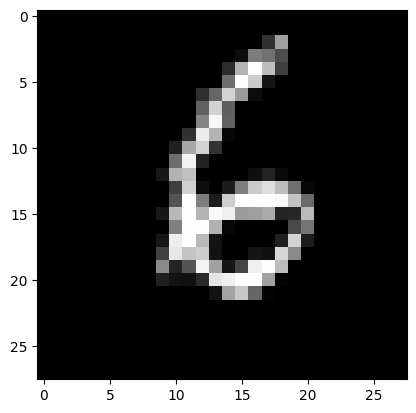

In [42]:
plt.imshow(x_test[2000].reshape(28,28),cmap='gray')
plt.show()


In [35]:
model.predict(x_test[2000])

array([6])

In [43]:
x_test[2000]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.19215686, 0.62352

In [39]:
print(x_test[2000].reshape(28,28).shape)

(28, 28)
